# EDA — Student Social Network

This notebook presents an Exploratory Data Analysis (EDA) of the student social network developed using Neo4j and the Graph Data Science (GDS) library.

The objective is to understand the structure and characteristics of the network, analyze the friendship relationships between students, and identify important students using different graph centrality measures.

The analysis covers:
- Dataset and graph statistics
- Friendship network structure
- Degree Centrality
- PageRank
- Betweenness Centrality
- Closeness Centrality
- Comparison of centrality rankings
- Visualizations and key observations

## 1. Introduction

The objective of this exploratory data analysis is to study the structure of a student social network modeled as a graph.

The network represents students and their interactions through friendship relationships. The analysis aims to understand the overall structure of the graph, identify connectivity patterns, and determine the most important students according to different definitions of centrality.

The main questions addressed in this analysis are:

- How large is the student social network?
- How are friendships distributed among students?
- Are there students with significantly more connections than others?
- Which students are the most connected?
- Which students are the most influential?
- Which students act as bridges between different parts of the network?
- Which students are best positioned to reach other students?
- How different centrality measures identify different types of important students?

## Environment and Configuration

In [1]:
import sys

print(sys.version)

3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from neo4j import GraphDatabase

In [13]:
import os
NEO4J_URI = "bolt://localhost:7687"
NEO4J_DATABASE = "neo4j"
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD",'password')

## Connection to Neo4j


In [14]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USERNAME, NEO4J_PASSWORD)
)

In [15]:
with driver.session(database=NEO4J_DATABASE) as session:
    result = session.run("RETURN 1 AS test")
    print(result.single()["test"])

1


In [30]:
def run_query(query, parameters=None):
    with driver.session(database=NEO4J_DATABASE) as session:
        result = session.run(query, parameters or {})
        return pd.DataFrame([record.data() for record in result])

In [31]:
result = run_query("""
MATCH (s:Student)
RETURN count(s) AS studentCount
""")

result

,studentCount
0,1500


## Dataset Overview

In [32]:
node_counts = run_query("""
MATCH (n)
UNWIND labels(n) AS label
RETURN label, count(*) AS count
ORDER BY count DESC
""")

node_counts

,label,count
0,Student,1500
1,Event,300
2,Club,70


In [33]:
relationship_counts = run_query("""
MATCH ()-[r]->()
RETURN type(r) AS relationshipType, count(*) AS count
ORDER BY count DESC
""")

relationship_counts

,relationshipType,count
0,A_PARTICIPE_A,19179
1,EST_AMI_DE,7465
2,MEMBRE_DE,2047


In [35]:
dataset_summary = pd.DataFrame({
    "Element": [
        "Students",
        "Clubs",
        "Events",
        "Friendships",
        "Memberships",
        "Event Participations"
    ],
    "Count": [
        node_counts.loc[node_counts["label"] == "Student", "count"].iloc[0],
        node_counts.loc[node_counts["label"] == "Club", "count"].iloc[0],
        node_counts.loc[node_counts["label"] == "Event", "count"].iloc[0],
        relationship_counts.loc[
            relationship_counts["relationshipType"] == "EST_AMI_DE",
            "count"
        ].iloc[0],
        relationship_counts.loc[
            relationship_counts["relationshipType"] == "MEMBRE_DE",
            "count"
        ].iloc[0],
        relationship_counts.loc[
            relationship_counts["relationshipType"] == "A_PARTICIPE_A",
            "count"
        ].iloc[0]
    ]
})

dataset_summary

,Element,Count
0,Students,1500
1,Clubs,70
2,Events,300
3,Friendships,7465
4,Memberships,2047
5,Event Participations,19179


### Dataset Overview

The graph database contains three main types of nodes: Students, Clubs, and Events. Students are connected to each other through friendship relationships and interact with clubs and events through membership and participation relationships.


## Graph Statistics

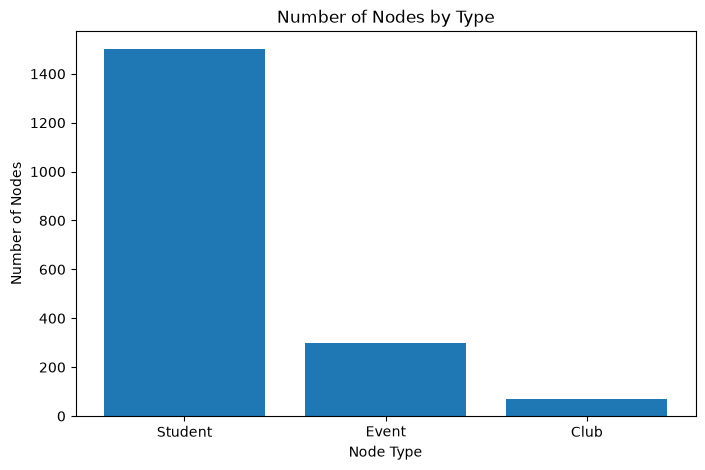

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    node_counts["label"],
    node_counts["count"]
)

plt.title("Number of Nodes by Type")
plt.xlabel("Node Type")
plt.ylabel("Number of Nodes")

plt.show()

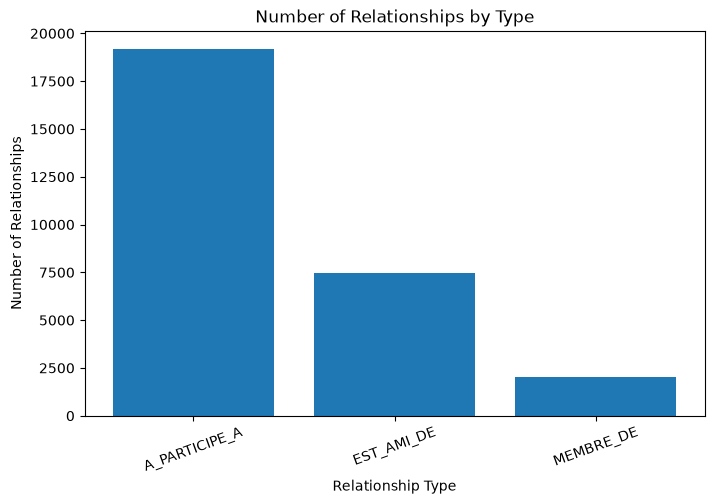

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    relationship_counts["relationshipType"],
    relationship_counts["count"]
)

plt.title("Number of Relationships by Type")
plt.xlabel("Relationship Type")
plt.ylabel("Number of Relationships")

plt.xticks(rotation=20)

plt.show()

In [39]:
degree_df = run_query("""
MATCH (s:Student)
OPTIONAL MATCH (s)-[:EST_AMI_DE]-(friend:Student)
WITH s, count(friend) AS degree
RETURN
    s.id AS studentId,
    s.nom AS name,
    degree
ORDER BY degree DESC
""")

degree_df.head()

,studentId,name,degree
0,6,Salmon Léon,148
1,10,Ribeiro Robert,147
2,7,Grégoire Josette,128
3,3,Guillot Nathalie,125
4,5,Leleu Éric,121


In [40]:
degree_stats = degree_df["degree"].describe()

degree_stats

count    1500.000000
mean        9.953333
std        11.954682
min         4.000000
25%         5.000000
50%         7.000000
75%        10.000000
max       148.000000
Name: degree, dtype: float64

In [41]:
degree_statistics = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"
    ],
    "Value": [
        degree_df["degree"].min(),
        degree_df["degree"].max(),
        degree_df["degree"].mean(),
        degree_df["degree"].median(),
        degree_df["degree"].std()
    ]
})

degree_statistics

,Statistic,Value
0,Minimum,4.000000
1,Maximum,148.000000
2,Mean,9.953333
3,Median,7.000000
4,Standard Deviation,11.954682


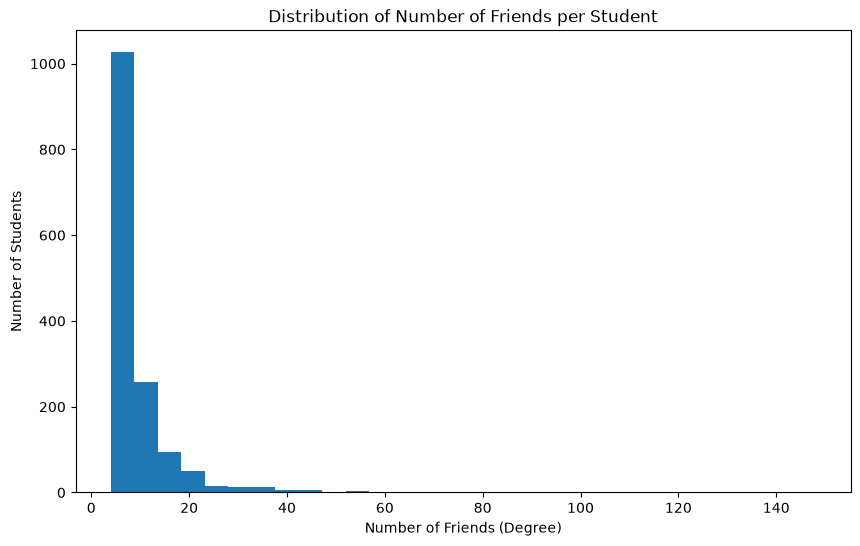

In [42]:
plt.figure(figsize=(10, 6))

plt.hist(
    degree_df["degree"],
    bins=30
)

plt.title("Distribution of Number of Friends per Student")
plt.xlabel("Number of Friends (Degree)")
plt.ylabel("Number of Students")

plt.show()

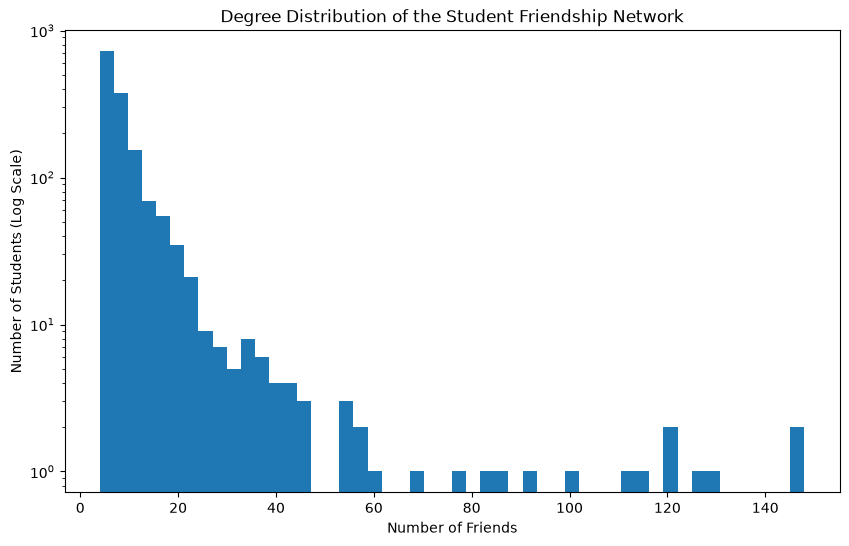

In [44]:
plt.figure(figsize=(10, 6))

plt.hist(
    degree_df["degree"],
    bins=50
)

plt.yscale("log")

plt.title("Degree Distribution of the Student Friendship Network")
plt.xlabel("Number of Friends")
plt.ylabel("Number of Students (Log Scale)")

plt.show()

## Friendship Network Analysis

In [45]:
friendship_count = run_query("""
MATCH (a:Student)-[:EST_AMI_DE]-(b:Student)
WHERE elementId(a) < elementId(b)
RETURN count(*) AS numberOfFriendships
""")

friendship_count

,numberOfFriendships
0,7465


In [46]:
average_degree = degree_df["degree"].mean()

print(f"Average number of friends: {average_degree:.2f}")

Average number of friends: 9.95


In [47]:
top_10_degree = (
    degree_df
    .sort_values("degree", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_10_degree.index += 1

top_10_degree

,studentId,name,degree
1,6,Salmon Léon,148
2,10,Ribeiro Robert,147
3,7,Grégoire Josette,128
4,3,Guillot Nathalie,125
5,5,Leleu Éric,121
6,11,Gautier Joseph,120
7,9,Moreau Frédéric,116
8,33,Guichard André,111
9,8,Chauveau Guy,100
10,13,Mercier Margaret,93


In [49]:
N = degree_df["studentId"].nunique()

E = friendship_count["numberOfFriendships"].iloc[0]

density = (2 * E) / (N * (N - 1))

print("Number of students:", N)
print("Number of friendships:", E)
print(f"Network density: {density:.6f}")

Number of students: 1500
Number of friendships: 7465
Network density: 0.006640


In [50]:
components_df = run_query("""
CALL gds.wcc.stream('studentFriendshipGraph')
YIELD componentId
RETURN
    componentId,
    count(*) AS numberOfStudents
ORDER BY numberOfStudents DESC
""")

components_df

,componentId,numberOfStudents
0,0,1500


In [51]:
number_of_components = len(components_df)

print("Number of connected components:", number_of_components)

Number of connected components: 1


In [52]:
largest_component = components_df["numberOfStudents"].max()

print(
    "Students in largest connected component:",
    largest_component
)

Students in largest connected component: 1500


In [53]:
centrality_df = run_query("""
MATCH (s:Student)
RETURN
    s.id AS studentId,
    s.nom AS name,
    s.degreeCentrality AS degree,
    s.pageRank AS pageRank,
    s.betweennessCentrality AS betweenness,
    s.closenessCentrality AS closeness
""")

centrality_df.head()

,studentId,name,degree,pageRank,betweenness,closeness
0,2,Guilbert Cécile,54.0,4.625114,18965.669244,0.396981
1,3,Guillot Nathalie,125.0,10.394004,75566.571296,0.459675
2,4,Guibert Laure,84.0,7.060900,40627.220475,0.424285
3,5,Leleu Éric,121.0,10.174220,71639.950920,0.451778
4,6,Salmon Léon,148.0,12.218951,97696.728981,0.476024


In [54]:
top_degree = (
    centrality_df
    .sort_values("degree", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_degree.index += 1

top_degree

,studentId,name,degree,pageRank,betweenness,closeness
1,6,Salmon Léon,148.0,12.218951,97696.728981,0.476024
2,10,Ribeiro Robert,147.0,12.242046,96106.162651,0.467707
3,7,Grégoire Josette,128.0,10.740790,81409.212662,0.458410
4,3,Guillot Nathalie,125.0,10.394004,75566.571296,0.459675
5,5,Leleu Éric,121.0,10.174220,71639.950920,0.451778
6,11,Gautier Joseph,120.0,9.926840,71734.622736,0.456178
7,9,Moreau Frédéric,116.0,9.587383,70225.267580,0.458130
8,33,Guichard André,111.0,9.416085,57096.619090,0.424766
9,8,Chauveau Guy,100.0,8.359333,51780.354367,0.441402
10,13,Mercier Margaret,93.0,7.846355,49248.238014,0.433488


In [55]:
top_degree.insert(
    0,
    "Rank",
    range(1, len(top_degree) + 1)
)

top_degree

,Rank,studentId,name,degree,pageRank,betweenness,closeness
1,1,6,Salmon Léon,148.0,12.218951,97696.728981,0.476024
2,2,10,Ribeiro Robert,147.0,12.242046,96106.162651,0.467707
3,3,7,Grégoire Josette,128.0,10.740790,81409.212662,0.458410
4,4,3,Guillot Nathalie,125.0,10.394004,75566.571296,0.459675
5,5,5,Leleu Éric,121.0,10.174220,71639.950920,0.451778
6,6,11,Gautier Joseph,120.0,9.926840,71734.622736,0.456178
7,7,9,Moreau Frédéric,116.0,9.587383,70225.267580,0.458130
8,8,33,Guichard André,111.0,9.416085,57096.619090,0.424766
9,9,8,Chauveau Guy,100.0,8.359333,51780.354367,0.441402
10,10,13,Mercier Margaret,93.0,7.846355,49248.238014,0.433488


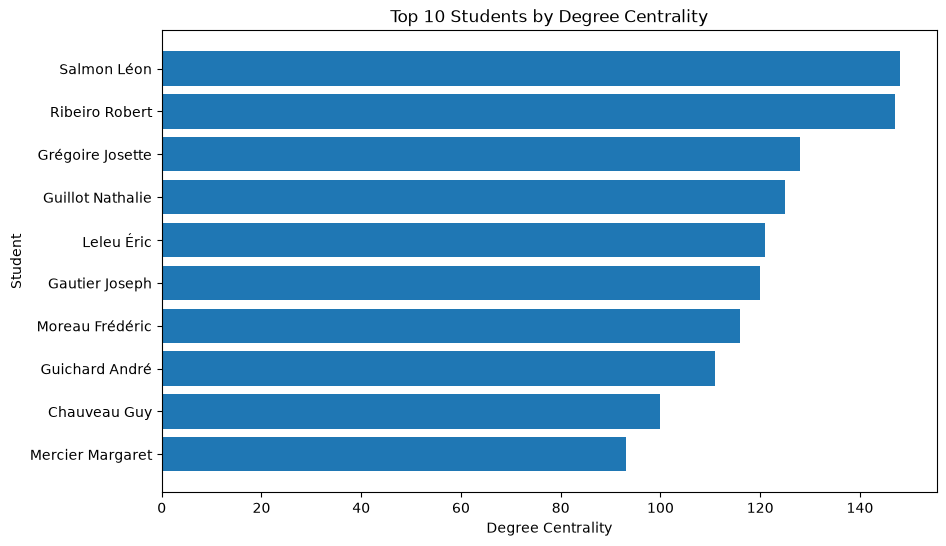

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_degree["name"].astype(str),
    top_degree["degree"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Students by Degree Centrality")
plt.xlabel("Degree Centrality")
plt.ylabel("Student")

plt.show()

In [57]:
top_pagerank = (
    centrality_df
    .sort_values("pageRank", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_pagerank.insert(
    0,
    "Rank",
    range(1, len(top_pagerank) + 1)
)

top_pagerank

,Rank,studentId,name,degree,pageRank,betweenness,closeness
0,1,10,Ribeiro Robert,147.0,12.242046,96106.162651,0.467707
1,2,6,Salmon Léon,148.0,12.218951,97696.728981,0.476024
2,3,7,Grégoire Josette,128.0,10.740790,81409.212662,0.458410
3,4,3,Guillot Nathalie,125.0,10.394004,75566.571296,0.459675
4,5,5,Leleu Éric,121.0,10.174220,71639.950920,0.451778
5,6,11,Gautier Joseph,120.0,9.926840,71734.622736,0.456178
6,7,9,Moreau Frédéric,116.0,9.587383,70225.267580,0.458130
7,8,33,Guichard André,111.0,9.416085,57096.619090,0.424766
8,9,8,Chauveau Guy,100.0,8.359333,51780.354367,0.441402
9,10,13,Mercier Margaret,93.0,7.846355,49248.238014,0.433488


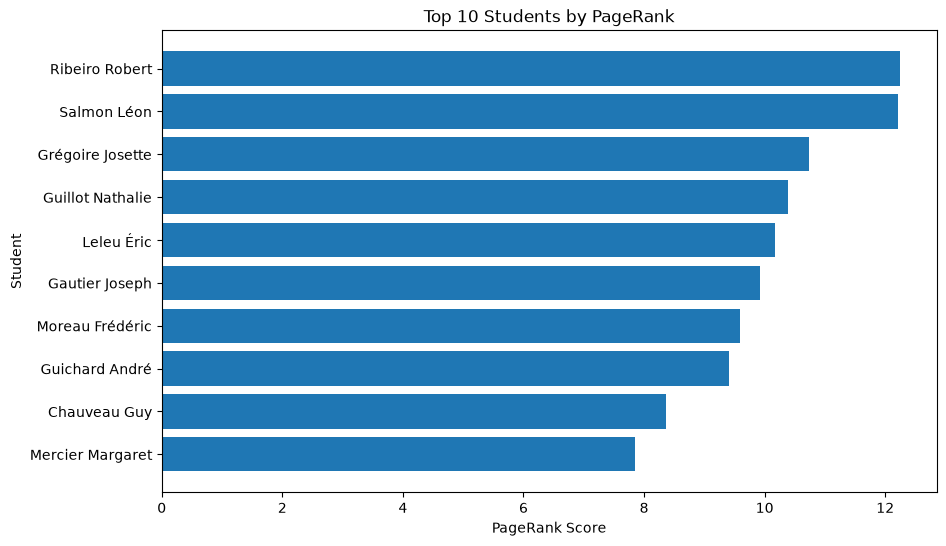

In [58]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_pagerank["name"].astype(str),
    top_pagerank["pageRank"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Students by PageRank")
plt.xlabel("PageRank Score")
plt.ylabel("Student")

plt.show()

In [59]:
top_betweenness = (
    centrality_df
    .sort_values("betweenness", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_betweenness.insert(
    0,
    "Rank",
    range(1, len(top_betweenness) + 1)
)

top_betweenness

,Rank,studentId,name,degree,pageRank,betweenness,closeness
0,1,6,Salmon Léon,148.0,12.218951,97696.728981,0.476024
1,2,10,Ribeiro Robert,147.0,12.242046,96106.162651,0.467707
2,3,7,Grégoire Josette,128.0,10.740790,81409.212662,0.458410
3,4,3,Guillot Nathalie,125.0,10.394004,75566.571296,0.459675
4,5,11,Gautier Joseph,120.0,9.926840,71734.622736,0.456178
5,6,5,Leleu Éric,121.0,10.174220,71639.950920,0.451778
6,7,9,Moreau Frédéric,116.0,9.587383,70225.267580,0.458130
7,8,33,Guichard André,111.0,9.416085,57096.619090,0.424766
8,9,8,Chauveau Guy,100.0,8.359333,51780.354367,0.441402
9,10,13,Mercier Margaret,93.0,7.846355,49248.238014,0.433488


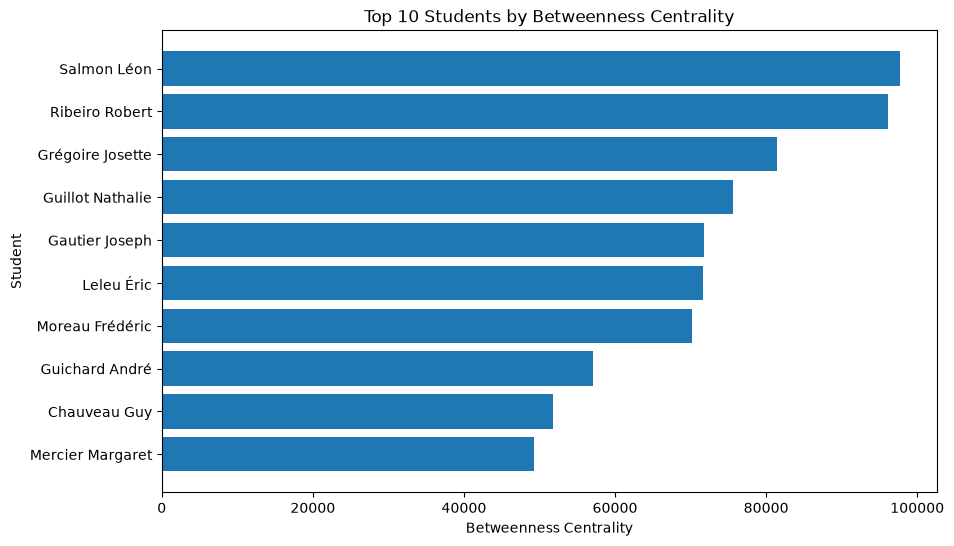

In [60]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_betweenness["name"].astype(str),
    top_betweenness["betweenness"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Students by Betweenness Centrality")
plt.xlabel("Betweenness Centrality")
plt.ylabel("Student")

plt.show()

In [61]:
top_closeness = (
    centrality_df
    .sort_values("closeness", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_closeness.insert(
    0,
    "Rank",
    range(1, len(top_closeness) + 1)
)

top_closeness

,Rank,studentId,name,degree,pageRank,betweenness,closeness
0,1,6,Salmon Léon,148.0,12.218951,97696.728981,0.476024
1,2,10,Ribeiro Robert,147.0,12.242046,96106.162651,0.467707
2,3,3,Guillot Nathalie,125.0,10.394004,75566.571296,0.459675
3,4,7,Grégoire Josette,128.0,10.740790,81409.212662,0.458410
4,5,9,Moreau Frédéric,116.0,9.587383,70225.267580,0.458130
5,6,11,Gautier Joseph,120.0,9.926840,71734.622736,0.456178
6,7,5,Leleu Éric,121.0,10.174220,71639.950920,0.451778
7,8,8,Chauveau Guy,100.0,8.359333,51780.354367,0.441402
8,9,13,Mercier Margaret,93.0,7.846355,49248.238014,0.433488
9,10,33,Guichard André,111.0,9.416085,57096.619090,0.424766


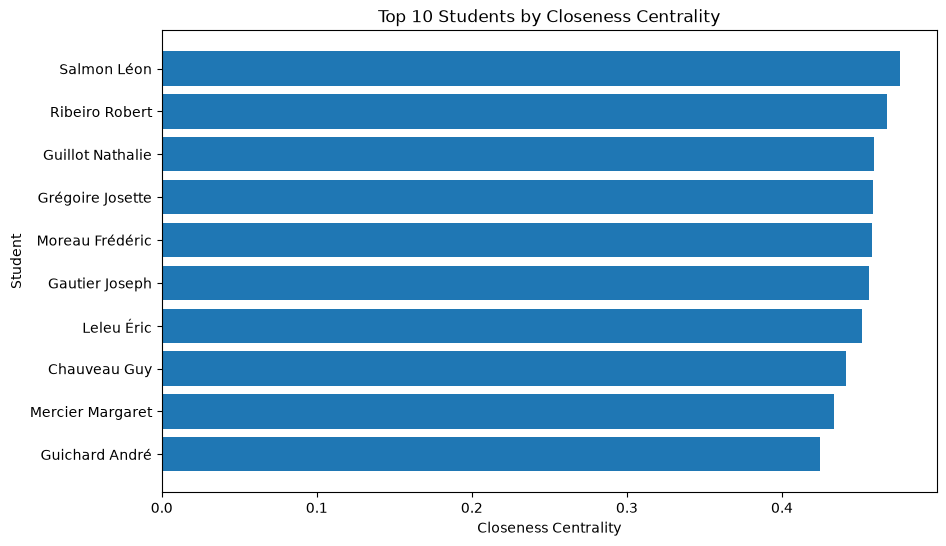

In [62]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_closeness["name"].astype(str),
    top_closeness["closeness"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Students by Closeness Centrality")
plt.xlabel("Closeness Centrality")
plt.ylabel("Student")

plt.show()

In [63]:
ranking_df = centrality_df.copy()

ranking_df["degreeRank"] = (
    ranking_df["degree"]
    .rank(method="min", ascending=False)
)

ranking_df["pageRankRank"] = (
    ranking_df["pageRank"]
    .rank(method="min", ascending=False)
)

ranking_df["betweennessRank"] = (
    ranking_df["betweenness"]
    .rank(method="min", ascending=False)
)

ranking_df["closenessRank"] = (
    ranking_df["closeness"]
    .rank(method="min", ascending=False)
)

ranking_df.head()

,studentId,name,degree,pageRank,betweenness,closeness,degreeRank,pageRankRank,betweennessRank,closenessRank
0,2,Guilbert Cécile,54.0,4.625114,18965.669244,0.396981,19.0,19.0,20.0,20.0
1,3,Guillot Nathalie,125.0,10.394004,75566.571296,0.459675,4.0,4.0,4.0,3.0
2,4,Guibert Laure,84.0,7.060900,40627.220475,0.424285,12.0,12.0,11.0,12.0
3,5,Leleu Éric,121.0,10.174220,71639.950920,0.451778,5.0,5.0,6.0,7.0
4,6,Salmon Léon,148.0,12.218951,97696.728981,0.476024,1.0,2.0,1.0,1.0


In [64]:
top10_students = set(
    top_degree["studentId"]
).union(
    top_pagerank["studentId"]
).union(
    top_betweenness["studentId"]
).union(
    top_closeness["studentId"]
)

comparison_df = ranking_df[
    ranking_df["studentId"].isin(top10_students)
].copy()

In [65]:
comparison_df = comparison_df[
    [
        "studentId",
        "name",
        "degreeRank",
        "pageRankRank",
        "betweennessRank",
        "closenessRank"
    ]
].sort_values("degreeRank")

comparison_df

,studentId,name,degreeRank,pageRankRank,betweennessRank,closenessRank
4,6,Salmon Léon,1.0,2.0,1.0,1.0
8,10,Ribeiro Robert,2.0,1.0,2.0,2.0
5,7,Grégoire Josette,3.0,3.0,3.0,4.0
1,3,Guillot Nathalie,4.0,4.0,4.0,3.0
3,5,Leleu Éric,5.0,5.0,6.0,7.0
9,11,Gautier Joseph,6.0,6.0,5.0,6.0
7,9,Moreau Frédéric,7.0,7.0,7.0,5.0
31,33,Guichard André,8.0,8.0,8.0,10.0
6,8,Chauveau Guy,9.0,9.0,9.0,8.0
11,13,Mercier Margaret,10.0,10.0,10.0,9.0


In [66]:
degree_top10_set = set(top_degree["studentId"])

pagerank_top10_set = set(top_pagerank["studentId"])

betweenness_top10_set = set(
    top_betweenness["studentId"]
)

closeness_top10_set = set(
    top_closeness["studentId"]
)

In [67]:
all_four = (
    degree_top10_set
    & pagerank_top10_set
    & betweenness_top10_set
    & closeness_top10_set
)

print("Students appearing in all four Top 10 rankings:")
print(all_four)

Students appearing in all four Top 10 rankings:
{'8', '13', '9', '3', '7', '33', '10', '11', '6', '5'}


In [68]:
from collections import Counter

all_top10 = (
    list(degree_top10_set)
    + list(pagerank_top10_set)
    + list(betweenness_top10_set)
    + list(closeness_top10_set)
)

overlap_counts = Counter(all_top10)

overlap_df = pd.DataFrame(
    overlap_counts.items(),
    columns=["studentId", "numberOfTop10Appearances"]
)

overlap_df = overlap_df.sort_values(
    "numberOfTop10Appearances",
    ascending=False
)

overlap_df

,studentId,numberOfTop10Appearances
0,8,4
1,13,4
2,9,4
3,3,4
4,7,4
5,33,4
6,10,4
7,11,4
8,6,4
9,5,4


In [69]:
centrality_columns = [
    "degree",
    "pageRank",
    "betweenness",
    "closeness"
]

correlation_matrix = centrality_df[
    centrality_columns
].corr()

correlation_matrix

,degree,pageRank,betweenness,closeness
degree,1.000000,0.999722,0.949260,0.680264
pageRank,0.999722,1.000000,0.946840,0.672562
betweenness,0.949260,0.946840,1.000000,0.580914
closeness,0.680264,0.672562,0.580914,1.000000


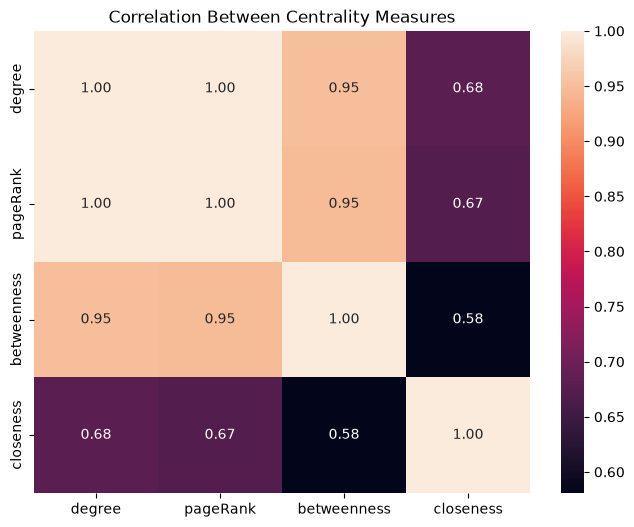

In [70]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Centrality Measures")

plt.show()

## Visualisations

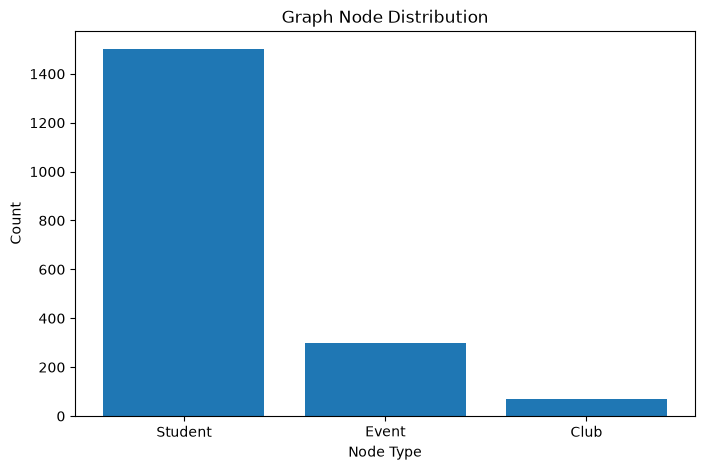

In [71]:
plt.figure(figsize=(8, 5))

plt.bar(
    node_counts["label"],
    node_counts["count"]
)

plt.title("Graph Node Distribution")
plt.xlabel("Node Type")
plt.ylabel("Count")

plt.show()

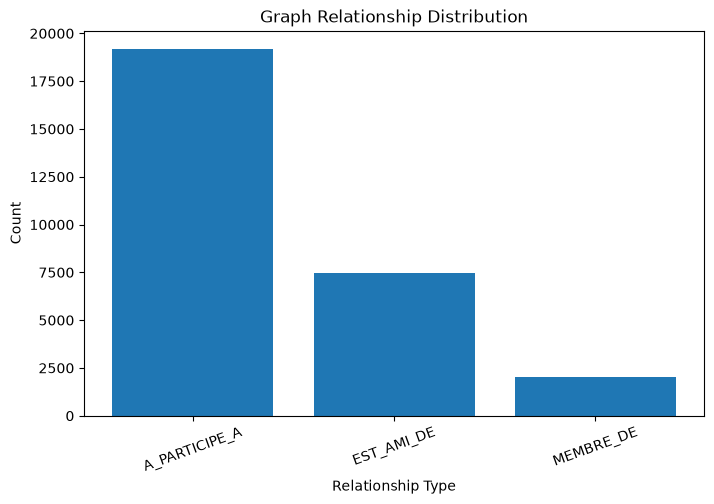

In [73]:
plt.figure(figsize=(8, 5))

plt.bar(
    relationship_counts["relationshipType"],
    relationship_counts["count"]
)

plt.title("Graph Relationship Distribution")
plt.xlabel("Relationship Type")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()